In [101]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [102]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [103]:
compact = True

In [104]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading 2024-09-30_21-16-21.parquet
Reading 2024-09-21_18-06-03.parquet
Reading 2024-09-30_22-14-40.parquet
Reading 2024-09-21_17-55-37.parquet
Reading 2024-09-21_10-15-05.parquet
Reading 2024-09-15_11-14-41.parquet
Reading combined_20240915100943.parquet
Reading 2024-09-30_21-29-18.parquet
Reading 2024-09-21_10-24-33.parquet
Reading 2024-09-15_11-18-29.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
b968f9ac-475f-4ce3-99bf-e10a167748a9,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],fold,0,0.4310,0.012930,0,"[5, 1, 0, 0, 0]",279.0,NaN
40ca191b-a3a6-4d41-8899-9ab5ac4f8866,None,[],"[94, 98]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.6276,0.025104,0,"[11, 10, 0, 0, 0]",465.0,NaN
f808b8aa-23f7-4bf4-b7c5-bbff1efe5168,40ca191b-a3a6-4d41-8899-9ab5ac4f8866,"[45, 18, 42]","[94, 94]",0,"[0, 4]","[4, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],fold,0,0.3821,0.022926,0,"[11, 10, 6, 5, 3]",465.0,NaN
dd0555b5-9484-4564-b36e-8c6e663b1bed,None,[],"[92, 102]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.5547,0.016641,0,"[11, 4, 0, 0, 0]",217.0,NaN
4762ad55-b994-40a2-bf66-89dd80ec997e,dd0555b5-9484-4564-b36e-8c6e663b1bed,"[46, 51, 1]","[90, 102]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.4682,0.018728,0,"[12, 11, 7, 4, 1]",217.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8a3533f2-e424-439e-9554-80fd7ebd6d77,None,[],"[80, 114]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],fold,0,0.5005,0.015015,0,"[9, 2, 0, 0, 0]",1069.0,NaN
967e17e0-39a0-41bb-bdb9-7db2999d59f3,None,[],"[76, 116]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.4033,0.016132,0,"[3, 1, 0, 0, 0]",637.0,NaN
0919cd80-2bcd-4830-bd3d-a1ba8539652f,967e17e0-39a0-41bb-bdb9-7db2999d59f3,"[21, 24, 35]","[76, 112]",0,"[0, 4]","[4, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],raise,20,0.3088,0.018528,0,"[11, 9, 8, 3, 1]",637.0,NaN


In [105]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [106]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [107]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players,is_all_in
6076184224,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.5985,0.017955,preflop,Tord,,2,False
5770114048,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.6170,0.018510,preflop,Arin,,2,False
6167147184,0,0,0,0,0,0,0,0,0,0,...,raise,6,0,0.5631,0.016893,preflop,Arin Bavian,,2,False
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c,0,0,0,0,0,0,0,0,0,0,...,fold,0,0,0.4939,0.029634,preflop,Henning,Max Mekker,2,False
6076273520,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.5014,0.015042,preflop,Tord,,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162184512,0,22,21,0,0,6,5,10,0,0,...,check,0,1,0.8571,0.565686,river,Arin,,2,False
6137322224,0,0,57,0,0,7,7,0,0,0,...,check,0,2,0.9750,0.711750,river,Arin,,2,True
4693928928,0,0,0,0,0,6,9,4,0,0,...,check,0,0,0.5191,0.109011,river,Arin,,2,False
6126809296,0,0,0,0,0,6,7,6,0,0,...,call,19,1,0.5474,0.166957,river,Arin,,2,False


In [108]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [109]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [110]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [111]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players,is_all_in
6076184224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Tord,,2,False
5770114048,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Arin,,2,False
6167147184,0,0,0,0,0,0,0,0,0,0,...,0,0,0,raise,6,preflop,Arin Bavian,,2,False
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,fold,0,preflop,Henning,Max Mekker,2,False
6076273520,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Tord,,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162184512,0,22,21,0,0,6,5,10,0,0,...,1,1,0,check,0,river,Arin,,2,False
6137322224,0,0,57,0,0,7,7,0,0,0,...,1,0,0,check,0,river,Arin,,2,True
4693928928,0,0,0,0,0,6,9,4,0,0,...,1,1,0,check,0,river,Arin,,2,False
6126809296,0,0,0,0,0,6,7,6,0,0,...,1,1,0,call,19,river,Arin,,2,False


In [112]:
y

6076184224                              0.5985
5770114048                              0.6170
6167147184                              0.5631
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c    0.4939
6076273520                              0.5014
                                         ...  
6162184512                              0.8571
6137322224                              0.9750
4693928928                              0.5191
6126809296                              0.5474
6137690960                              0.9647
Name: p, Length: 6909, dtype: float64

In [113]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [114]:
# Grouped train-test split
np.random.seed(42)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5518, 37)
Test shape: (1391, 37)


In [115]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [116]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16043282173968962
MAE: 0.12178195100357501
MAPE: 38.14%


,y_test,y_pred
6148857040,0.3471,0.411528
a0c2e9c3-4062-46c7-b0f3-bd294aeef514,0.5548,0.534995
6127529072,0.5130,0.517797
20ee65c0-7ffe-44b7-8b05-d9b282980c7b,0.4800,0.441873
94ff3a0f-c4c5-469f-876c-81fa7adeac0f,0.5215,0.501934
...,...,...
8b01e60d-e225-4e4a-a6d8-8018bacf7507,0.6796,0.620266
7b9d72a6-86c2-43c7-82e8-3ec27668819d,0.9988,0.465739
6099661344,0.7624,0.543726
6299785584,0.1990,0.534095


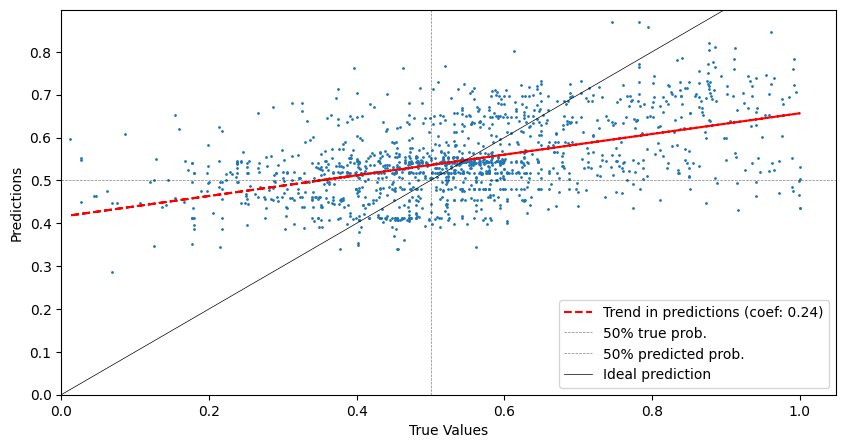

In [117]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [118]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
38,opponent_call_showdown,-3.297307e+10,3.297307e+10
18,raise_showdown,3.297307e+10,3.297307e+10
40,opponent_check_flop,5.878070e+09,5.878070e+09
20,call_flop,-5.878070e+09,5.878070e+09
39,opponent_check_preflop,3.804284e+09,3.804284e+09
19,call_preflop,-3.804284e+09,3.804284e+09
21,call_turn,1.798462e+09,1.798462e+09
41,opponent_check_turn,-1.798462e+09,1.798462e+09
28,check_showdown,-1.740418e+09,1.740418e+09
43,opponent_check_showdown,1.740418e+09,1.740418e+09


### Compare to XGBoost

In [119]:
from xgboost import XGBRegressor

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "regressor",
            XGBRegressor(
                colsample_bytree=0.6,
                learning_rate=0.1,
                max_depth=3,
                n_estimators=500,
                subsample=1.0,
            ),
        ),
    ]
)

In [120]:
cross_validate = False

In [121]:
if cross_validate:
    # Cross validate to find good hyperparameters
    from sklearn.model_selection import GridSearchCV

    # Define the parameter grid
    param_grid = {
        'regressor__n_estimators': [100, 500],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__max_depth': [3, 5, 7],
        'regressor__subsample': [0.6, 0.8, 1.0],
        'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    }

    # Grid search over the XGBRegressor parameters
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Best parameters and score
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    
    # Use the best model
    model = grid_search.best_estimator_

In [122]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.6, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [123]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df["player_name"] = df.iloc[test_idx]["player_name"]
pred_df

RMSE: 0.15944505994202673
MAE: 0.1175936039163591
MAPE: 36.55%


,y_test,y_pred,player_name
6148857040,0.3471,0.424221,Arin
a0c2e9c3-4062-46c7-b0f3-bd294aeef514,0.5548,0.550768,Jacob
6127529072,0.5130,0.506325,Tord
20ee65c0-7ffe-44b7-8b05-d9b282980c7b,0.4800,0.516368,Finn
94ff3a0f-c4c5-469f-876c-81fa7adeac0f,0.5215,0.559310,Finn
...,...,...,...
8b01e60d-e225-4e4a-a6d8-8018bacf7507,0.6796,0.686667,Tord
7b9d72a6-86c2-43c7-82e8-3ec27668819d,0.9988,0.346771,Tord
6099661344,0.7624,0.502324,Arin
6299785584,0.1990,0.287699,Arin


In [124]:
pred_df["square"] = (pred_df["y_test"] - pred_df["y_pred"])**2
(pred_df.pivot_table("square", "player_name", aggfunc="mean")**(1/2)).sort_values(by="square")

,square
player_name,
Syver,0.107292
Alun,0.129221
Arin Bavian,0.142350
t,0.145451
Arin,0.150637
Finn,0.154753
Tord,0.164320
Jacob,0.174545
Henning,0.186533


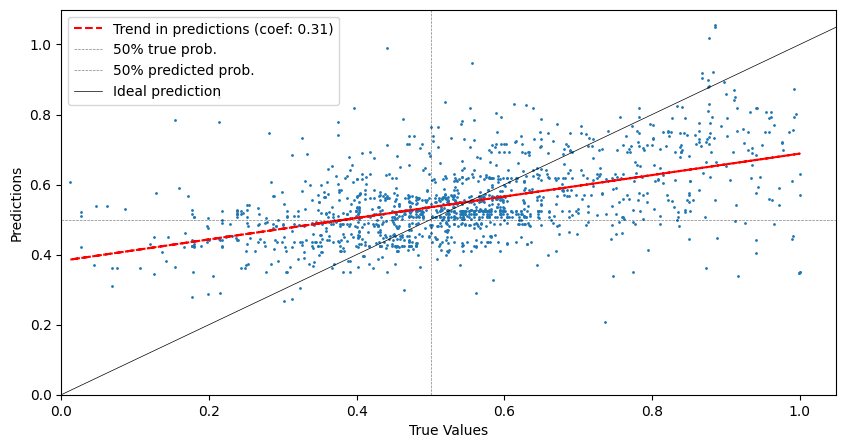

In [125]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()